<h1><center>EE69210: Machine Learning for Signal Processing Laboratory</center></h1>
<h2><center>Experiment-8: Neural Networks </center></h2>
<h3><center>Anirvan Krishna | 21EE38002</center></h3>

In [47]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import OrderedDict
from torchsummary import summary
import torch.nn.functional as F
import seaborn as sns

from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Dataset Preparation

In [48]:
# Create transformation to convert data to tensors
transform = transforms.Compose([transforms.ToTensor()])

# Load Fashion MNIST datasets
train_dataset = datasets.FashionMNIST('F_MNIST_data', download=True, train=True, transform=transform)
test_dataset = datasets.FashionMNIST('F_MNIST_data', download=True, train=False, transform=transform)

# Split train set into training (80%) and validation set (20%)
train_len = len(train_dataset)
indices = list(range(train_len))
np.random.shuffle(indices)
split = int(np.floor(0.2 * train_len))
val_ids, train_ids = indices[:split], indices[split:]

# Prepare dataloaders
train_sampler = torch.utils.data.sampler.SubsetRandomSampler(train_ids)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, 
                                           sampler=train_sampler, num_workers=4,
                                           pin_memory=True if torch.cuda.is_available() else False)

val_sampler = torch.utils.data.sampler.SubsetRandomSampler(val_ids)
val_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, 
                                         sampler=val_sampler, num_workers=4,
                                         pin_memory=True if torch.cuda.is_available() else False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, 
                                          shuffle=True, num_workers=4,
                                          pin_memory=True if torch.cuda.is_available() else False)


Length of train data is 48000
Length of test data is 10000
Length of validation data is 12000
Image Shape: torch.Size([1, 28, 28]), Label shape:  torch.Size([128])
Label: Ankle Boot


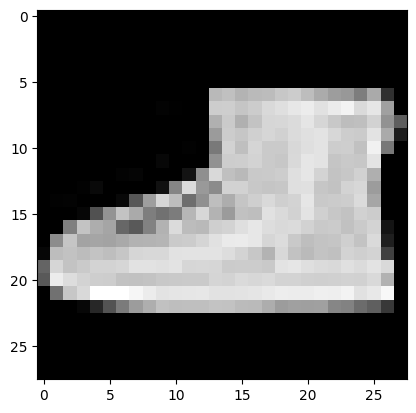

In [49]:
print("Length of train data is " + str(len(train_sampler)))
print("Length of test data is " + str(len(test_dataset)))
print("Length of validation data is " + str(len(val_sampler)))

image, label = next(iter(train_loader))
print(f"Image Shape: {image[0].shape}, Label shape:  {label.shape}")

desc = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 
    'Sneaker', 'Bag', 'Ankle Boot']

print(f"Label: {desc[label[0].item()]}")

# Display the first image
plt.imshow(image[0].numpy().squeeze(), cmap='gray')


## Model Definitions

### Normal

In [50]:
class FCNetwork1(nn.Module):
    def __init__(self):
        super(FCNetwork1, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 392),
            nn.ReLU(),
            nn.Linear(392, 196),
            nn.ReLU(),
            nn.Linear(196, 98),
            nn.ReLU(),
            nn.Linear(98, 49),
            nn.ReLU(),
            nn.Linear(49, 10),
        )
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.layers(x)
        return x        

In [51]:
summary(FCNetwork1().to('cuda'), (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 392]         307,720
              ReLU-2                  [-1, 392]               0
            Linear-3                  [-1, 196]          77,028
              ReLU-4                  [-1, 196]               0
            Linear-5                   [-1, 98]          19,306
              ReLU-6                   [-1, 98]               0
            Linear-7                   [-1, 49]           4,851
              ReLU-8                   [-1, 49]               0
            Linear-9                   [-1, 10]             500
Total params: 409,405
Trainable params: 409,405
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 1.56
Estimated Total Size (MB): 1.58
-------------------------------------------

### With Dropout

In [52]:
class FCNetwork2(nn.Module):
    def __init__(self):
        super(FCNetwork2, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 392),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(392, 196),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(196, 98),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(98, 49),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(49, 10),
        )
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.layers(x)
        return x        

In [53]:
summary(FCNetwork2().to('cuda'), (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 392]         307,720
              ReLU-2                  [-1, 392]               0
           Dropout-3                  [-1, 392]               0
            Linear-4                  [-1, 196]          77,028
              ReLU-5                  [-1, 196]               0
           Dropout-6                  [-1, 196]               0
            Linear-7                   [-1, 98]          19,306
              ReLU-8                   [-1, 98]               0
           Dropout-9                   [-1, 98]               0
           Linear-10                   [-1, 49]           4,851
             ReLU-11                   [-1, 49]               0
          Dropout-12                   [-1, 49]               0
           Linear-13                   [-1, 10]             500
Total params: 409,405
Trainable params:

In [54]:
class FCNetwork3(nn.Module):
    def __init__(self):
        super(FCNetwork3, self).__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(784, 392),
            nn.ReLU(),
            nn.BatchNorm1d(392),
            nn.Linear(392, 196),
            nn.ReLU(),
            nn.BatchNorm1d(196),
            nn.Linear(196, 98),
            nn.ReLU(),
            nn.BatchNorm1d(98),
            nn.Linear(98, 49),
            nn.ReLU(),
            nn.BatchNorm1d(49),
            nn.Linear(49, 10),
        )
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.layers(x)
        return x        

In [55]:
summary(FCNetwork3().to('cuda'), (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 392]         307,720
              ReLU-2                  [-1, 392]               0
       BatchNorm1d-3                  [-1, 392]             784
            Linear-4                  [-1, 196]          77,028
              ReLU-5                  [-1, 196]               0
       BatchNorm1d-6                  [-1, 196]             392
            Linear-7                   [-1, 98]          19,306
              ReLU-8                   [-1, 98]               0
       BatchNorm1d-9                   [-1, 98]             196
           Linear-10                   [-1, 49]           4,851
             ReLU-11                   [-1, 49]               0
      BatchNorm1d-12                   [-1, 49]              98
           Linear-13                   [-1, 10]             500
Total params: 410,875
Trainable params:

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Functions for Train and Test

In [57]:
def test_model(model, dataloader, criterion, device):
    
    model.eval()
    test_accuracy = []
    test_losses = []

    with torch.no_grad(): 
        for test_img, test_label in dataloader:
            test_img, test_label = test_img.to(device), test_label.to(device)
            test_out = model(test_img)
            
            # Compute loss
            loss = criterion(test_out, test_label)
            test_losses.append(loss.item())

            # Compute accuracy
            _, test_out = torch.max(test_out, 1)
            test_acc = (torch.sum(test_out == test_label).item() / test_label.size(0))
            test_accuracy.append(test_acc)
       
    mean_accuracy = sum(test_accuracy) / len(test_accuracy)
    mean_loss = sum(test_losses) / len(test_losses)

    return mean_loss, mean_accuracy


In [58]:
def train(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=10):
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    train_accuracies = []

    for epoch in range(n_epochs):
        
        model.train()
        
        print(
        f'=====================================[Epoch: {epoch+1}/{n_epochs}]=========================================\n'
        )
        
        loss_train = 0
        train_accuracy = []

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device).long()

            optimizer.zero_grad()
            preds = model(images)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

            # Accumulate loss
            loss_train += loss.item() * images.size(0)

            # Compute accuracy per batch
            _, predicted = torch.max(preds, 1)
            batch_acc = (torch.sum(predicted == labels).item() / labels.size(0)) 
            train_accuracy.append(batch_acc)

        # Compute mean accuracy & loss
        loss_train /= len(train_loader.dataset)
        mean_train_accuracy = sum(train_accuracy) / len(train_accuracy)

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_loss, val_accuracy = test_model(model, val_loader, criterion, device)
            
        train_losses.append(loss_train)
        train_accuracies.append(mean_train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
    
        print(f"Train Loss: {loss_train:.4f}\tTrain Accuracy: {mean_train_accuracy*100:.2f} %\nVal Loss: {val_loss:.4f}\tVal Accuracy: {val_accuracy*100:.2f} %\n")
        print("_"*100)

    return train_losses, val_losses, train_accuracies, val_accuracies


In [59]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies):
    
    fig, axs = plt.subplots(1, 2, figsize=(20, 5))

    axs[0].plot(train_losses, label='Train Loss', color='blue')
    axs[0].plot(val_losses, label='Validation Loss', color='red')
    axs[0].set_title('Loss Plots')
    axs[0].legend()

    axs[1].plot(train_accuracies, label='Train Accuracy', color='blue')
    axs[1].plot(val_accuracies, label='Validation Accuracy', color='red')
    axs[1].set_title('Accuracy Plots')
    axs[1].legend()

    plt.show()

def test_metrics(model, test_loader):
    """
    Plot confusion matrix and classification report on the test loader
    """

    y_true = []
    y_pred = []

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).long()

        preds = model(images)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.argmax(1).cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print(f"Classification Report: \n{classification_report(y_true, y_pred)}")

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    fig, ax = plt.subplots(figsize=(10, 8))
   
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=desc)
    disp.plot(cmap='Blues', ax=ax)

## Experiments

#### Model-1

In [60]:
model1 = FCNetwork1().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.0001)
n_epochs = 50

train_losses1, val_losses1, train_accuracies1, val_accuracies1 = train(
    model1, train_loader, val_loader, optimizer, criterion, device, n_epochs)

=====================================[Epoch: 1/50]=========================================



100%|██████████| 375/375 [00:02<00:00, 139.55it/s]


Train Loss: 0.9218	Train Accuracy: 61.59 %
Val Loss: 0.6636	Val Accuracy: 76.55 %

____________________________________________________________________________________________________
=====================================[Epoch: 2/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 122.24it/s]


Train Loss: 0.4788	Train Accuracy: 78.66 %
Val Loss: 0.5445	Val Accuracy: 80.40 %

____________________________________________________________________________________________________
=====================================[Epoch: 3/50]=========================================



...

Train Loss: 0.1627	Train Accuracy: 92.57 %
Val Loss: 0.3092	Val Accuracy: 89.59 %

____________________________________________________________________________________________________
=====================================[Epoch: 49/50]=========================================



100%|██████████| 375/375 [00:02<00:00, 138.53it/s]


Train Loss: 0.1630	Train Accuracy: 92.59 %
Val Loss: 0.3142	Val Accuracy: 89.54 %

____________________________________________________________________________________________________
=====================================[Epoch: 50/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 118.47it/s]


Train Loss: 0.1586	Train Accuracy: 92.82 %
Val Loss: 0.3236	Val Accuracy: 89.24 %

____________________________________________________________________________________________________


Classification Report: 
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.86      0.74      0.80      1000
           3       0.84      0.92      0.88      1000
           4       0.82      0.77      0.80      1000
           5       0.97      0.95      0.96      1000
           6       0.67      0.76      0.71      1000
           7       0.92      0.97      0.94      1000
           8       0.96      0.96      0.96      1000
           9       0.97      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



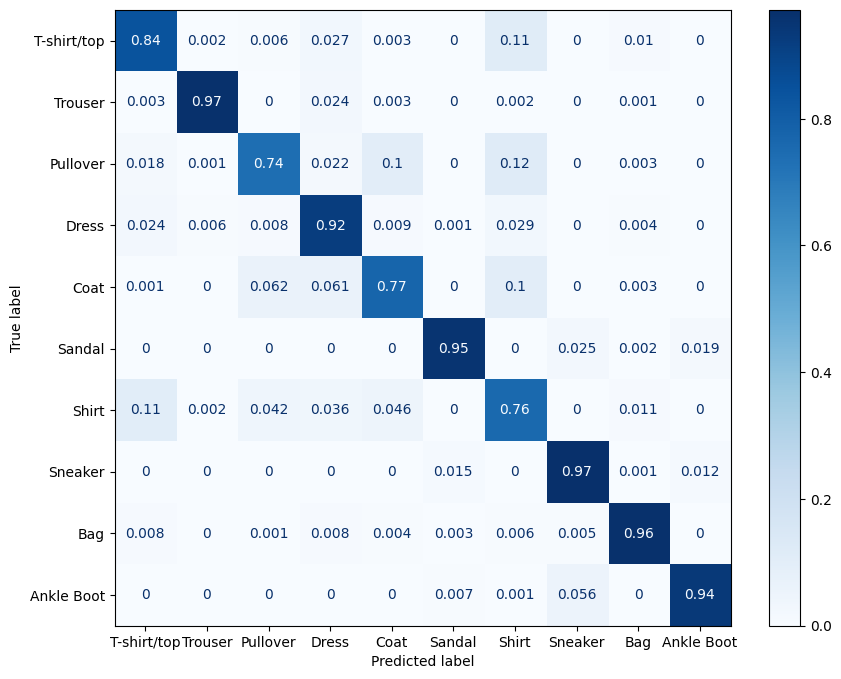

In [61]:
test_metrics(model1, test_loader)

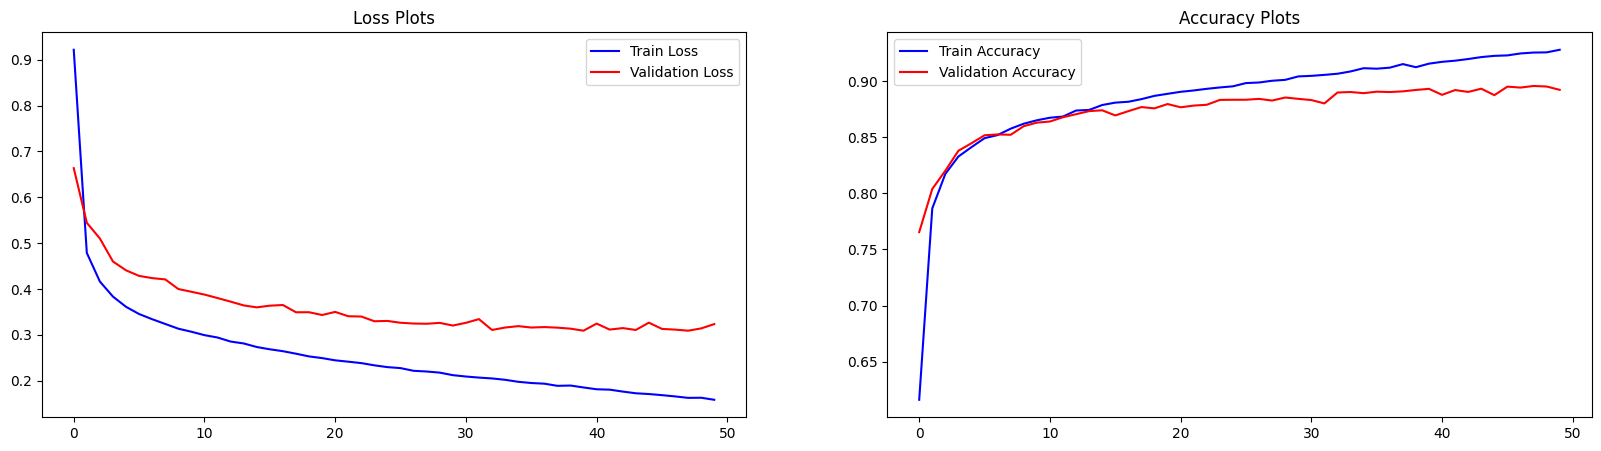

In [62]:
plot_metrics(train_losses1, val_losses1, train_accuracies1, val_accuracies1)

#### Model-2

In [63]:
model2 = FCNetwork2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.0001)
n_epochs = 50

train_losses2, val_losses2, train_accuracies2, val_accuracies2 = train(
    model2, train_loader, val_loader, optimizer, criterion, device, n_epochs)

=====================================[Epoch: 1/50]=========================================



100%|██████████| 375/375 [00:02<00:00, 127.74it/s]


Train Loss: 1.1912	Train Accuracy: 41.94 %
Val Loss: 0.8305	Val Accuracy: 68.06 %

____________________________________________________________________________________________________
=====================================[Epoch: 2/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 108.72it/s]


Train Loss: 0.6861	Train Accuracy: 67.39 %
Val Loss: 0.6404	Val Accuracy: 77.31 %

____________________________________________________________________________________________________
=====================================[Epoch: 3/50]=========================================



...

Train Loss: 0.1841	Train Accuracy: 91.79 %
Val Loss: 0.3123	Val Accuracy: 89.68 %

____________________________________________________________________________________________________
=====================================[Epoch: 49/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 117.38it/s]


Train Loss: 0.1828	Train Accuracy: 91.98 %
Val Loss: 0.3060	Val Accuracy: 90.10 %

____________________________________________________________________________________________________
=====================================[Epoch: 50/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 105.86it/s]


Train Loss: 0.1803	Train Accuracy: 92.05 %
Val Loss: 0.3030	Val Accuracy: 90.13 %

____________________________________________________________________________________________________


Classification Report: 
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1000
           1       0.99      0.97      0.98      1000
           2       0.85      0.77      0.81      1000
           3       0.89      0.89      0.89      1000
           4       0.79      0.85      0.82      1000
           5       0.97      0.96      0.97      1000
           6       0.71      0.72      0.72      1000
           7       0.94      0.97      0.95      1000
           8       0.97      0.98      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



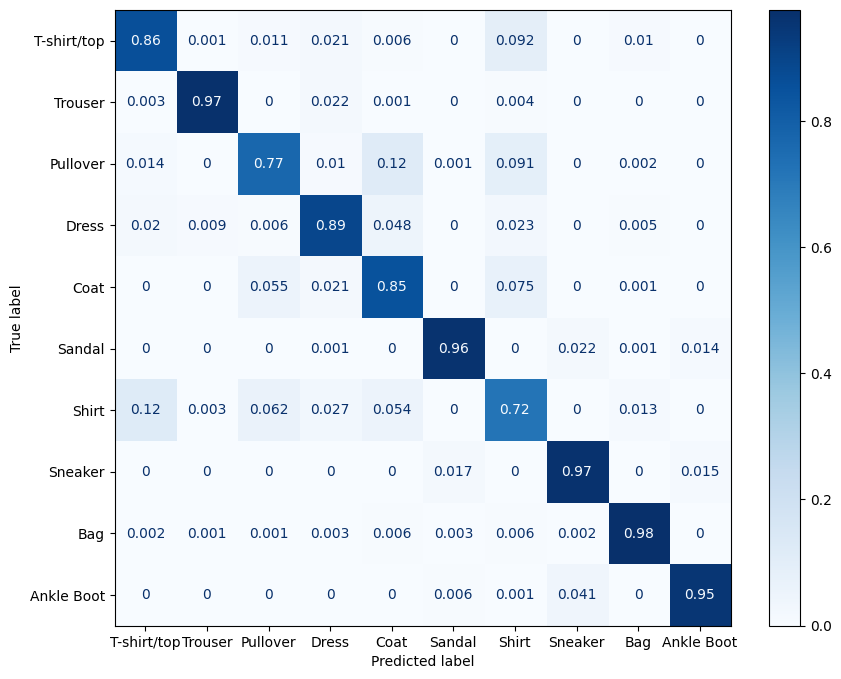

In [64]:
test_metrics(model2, test_loader)

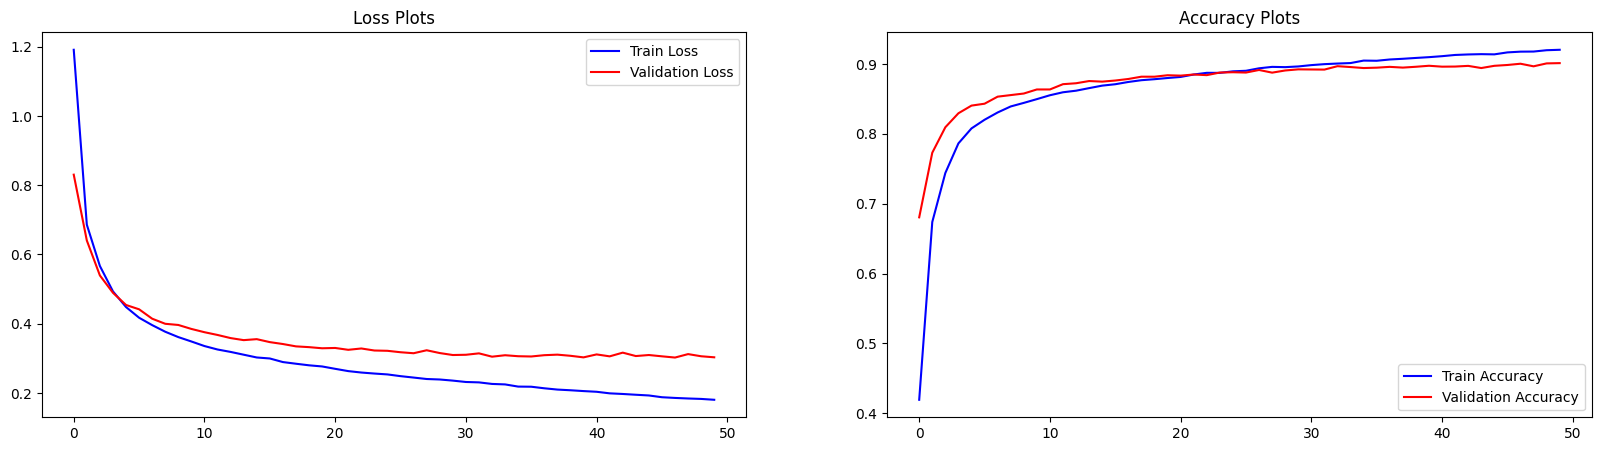

In [65]:
plot_metrics(train_losses2, val_losses2, train_accuracies2, val_accuracies2)

#### Model-3

In [66]:
model3 = FCNetwork3().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.0001)
n_epochs = 50

train_losses3, val_losses3, train_accuracies3, val_accuracies3 = train(
    model3, train_loader, val_loader, optimizer, criterion, device, n_epochs)

=====================================[Epoch: 1/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 101.42it/s]


Train Loss: 0.6221	Train Accuracy: 80.03 %
Val Loss: 0.5035	Val Accuracy: 85.78 %

____________________________________________________________________________________________________
=====================================[Epoch: 2/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 100.31it/s]


Train Loss: 0.3514	Train Accuracy: 86.74 %
Val Loss: 0.4037	Val Accuracy: 87.17 %

____________________________________________________________________________________________________
=====================================[Epoch: 3/50]=========================================



...

Train Loss: 0.0339	Train Accuracy: 98.49 %
Val Loss: 0.4932	Val Accuracy: 89.01 %

____________________________________________________________________________________________________
=====================================[Epoch: 49/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 107.64it/s]


Train Loss: 0.0358	Train Accuracy: 98.39 %
Val Loss: 0.4951	Val Accuracy: 88.87 %

____________________________________________________________________________________________________
=====================================[Epoch: 50/50]=========================================



100%|██████████| 375/375 [00:03<00:00, 96.30it/s] 


Train Loss: 0.0301	Train Accuracy: 98.64 %
Val Loss: 0.5024	Val Accuracy: 88.95 %

____________________________________________________________________________________________________


Classification Report: 
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.81      0.81      0.81      1000
           3       0.87      0.89      0.88      1000
           4       0.82      0.81      0.82      1000
           5       0.98      0.96      0.97      1000
           6       0.71      0.67      0.69      1000
           7       0.95      0.95      0.95      1000
           8       0.96      0.97      0.97      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



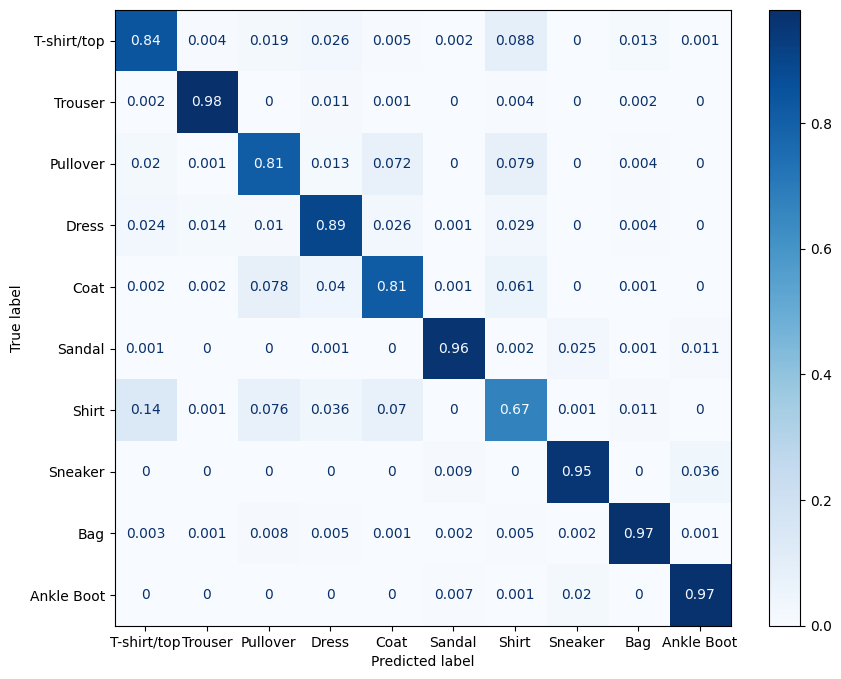

In [67]:
test_metrics(model3, test_loader)

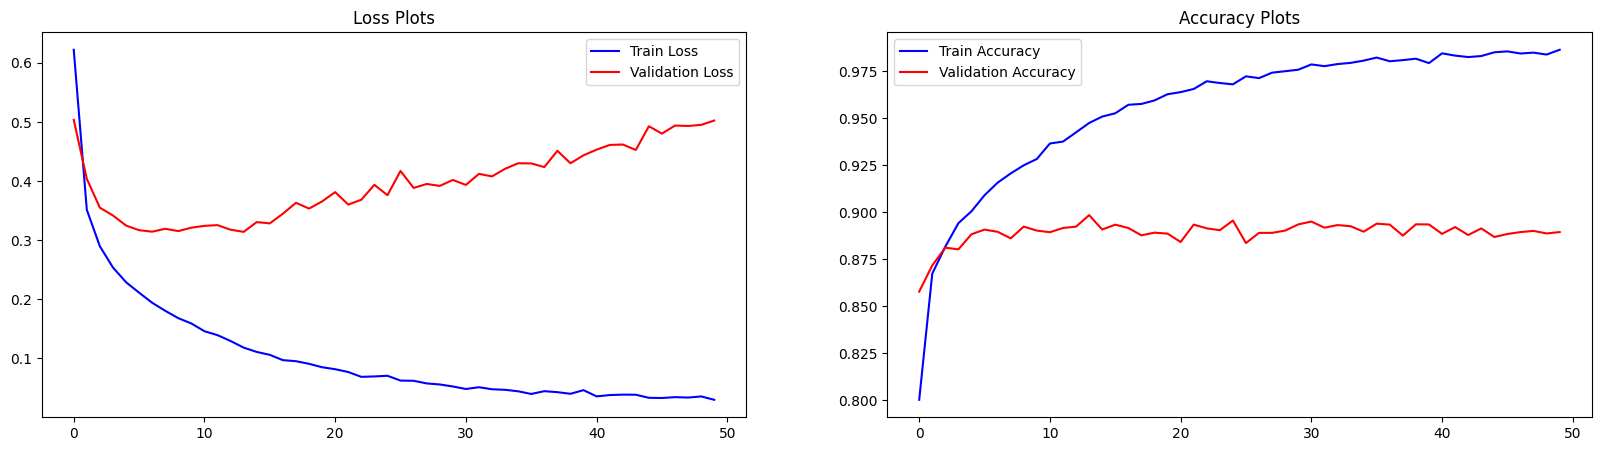

In [68]:
plot_metrics(train_losses3, val_losses3, train_accuracies3, val_accuracies3)

## Model Comparision

Text(0, 0.5, 'Accuracy')

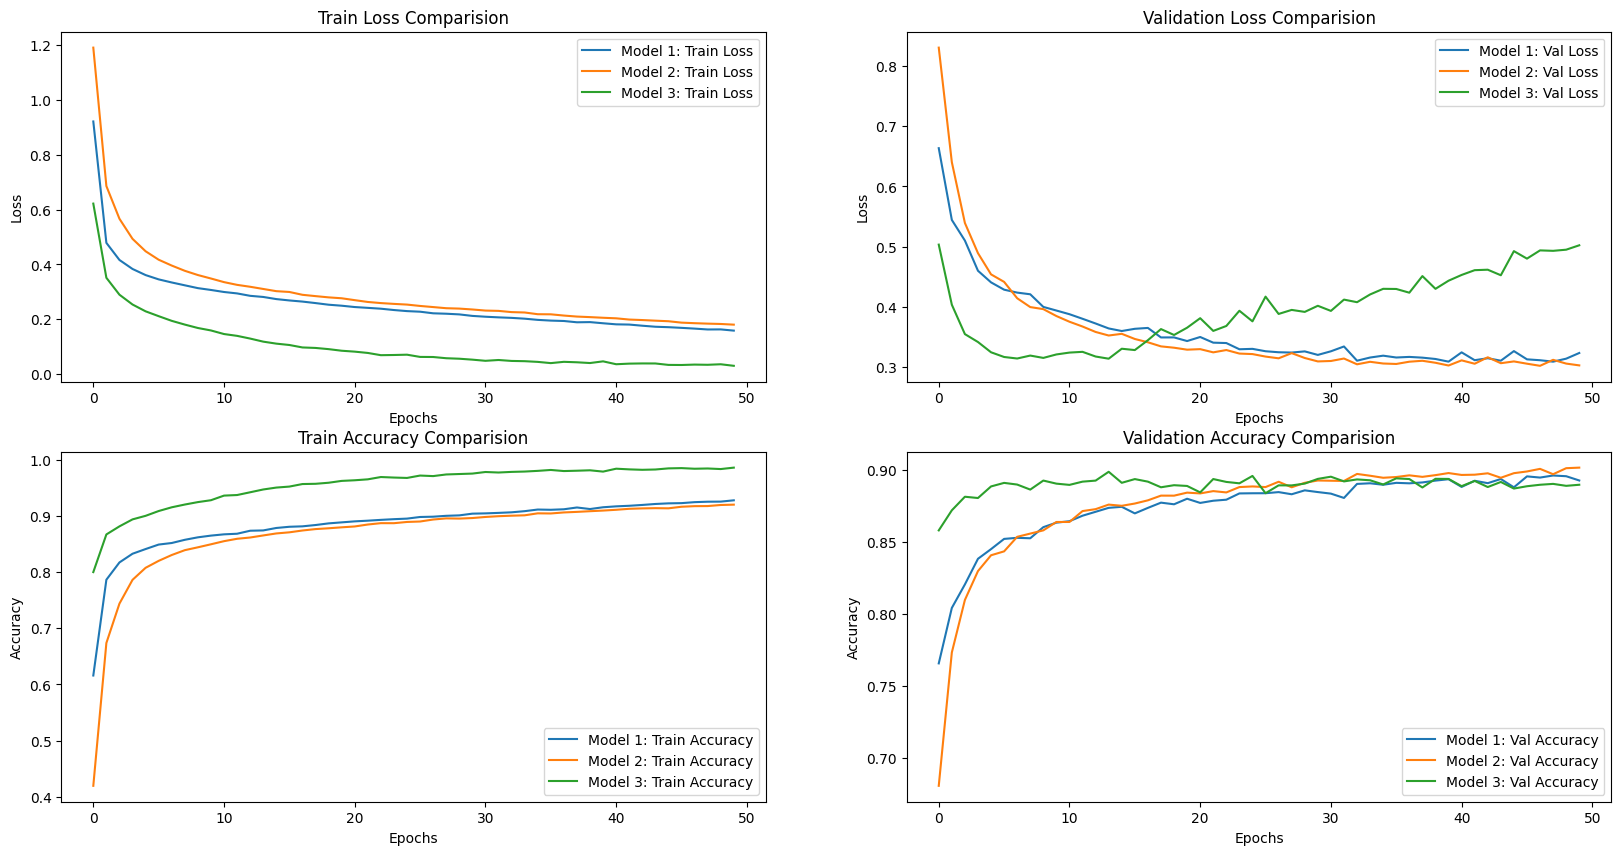

In [71]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 2, 1)

plt.plot(train_losses1, label='Model 1: Train Loss')
plt.plot(train_losses2, label='Model 2: Train Loss')
plt.plot(train_losses3, label='Model 3: Train Loss')

plt.title('Train Loss Comparision')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(2, 2, 2)

plt.plot(val_losses1, label='Model 1: Val Loss')
plt.plot(val_losses2, label='Model 2: Val Loss')
plt.plot(val_losses3, label='Model 3: Val Loss')

plt.title('Validation Loss Comparision')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')


plt.subplot(2, 2, 3)

plt.plot(train_accuracies1, label='Model 1: Train Accuracy')
plt.plot(train_accuracies2, label='Model 2: Train Accuracy')
plt.plot(train_accuracies3, label='Model 3: Train Accuracy')

plt.title('Train Accuracy Comparision')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(2, 2, 4)

plt.plot(val_accuracies1, label='Model 1: Val Accuracy')
plt.plot(val_accuracies2, label='Model 2: Val Accuracy')
plt.plot(val_accuracies3, label='Model 3: Val Accuracy')

plt.title('Validation Accuracy Comparision')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
